<a href="https://colab.research.google.com/github/sanjivinicarmel/AgriDataAnalysis2016/blob/main/Convolutional_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective**

To build a Convolutional Autoencoder (CAE) that compresses facial images into a lower-dimensional latent representation and reconstructs them with minimal loss of information.

**Purpose**

A Convolutional Autoencoder is an unsupervised deep learning model used for:

Image Compression
Image Reconstruction
Feature Extraction
Dimensionality Reduction

The encoder learns a compressed representation (latent space), while the decoder reconstructs the original image from this compressed representation.

In [1]:
#Libraries
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [2]:
#Install Kaggle
!pip install -q kaggle

In [3]:
#Upload Kaggle API
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sanjivini","key":"ea5ebbcb05f38d759ad4e81ed0269d35"}'}

In [4]:
#Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
#Download Dataset
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:15<00:00, 93.3MB/s]



In [6]:
#Extract Dataset
!unzip -q celeba-dataset.zip

In [10]:
import os
import shutil

#Create a Smaller Dataset (5000 Images)
source_folder = os.path.join("img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )

print("Copied", len(images), "images")

Copied 5000 images


In [11]:
#Data Preprocessing
IMAGE_SIZE = (64,64)

BATCH_SIZE = 32

In [12]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [13]:
#Load Dataset
train_generator = datagen.flow_from_directory(

    "celeba_small",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="input",

    subset="training"

)

Found 4000 images belonging to 1 classes.


In [14]:
validation_generator = datagen.flow_from_directory(

    "celeba_small",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="input",

    subset="validation"

)

Found 1000 images belonging to 1 classes.


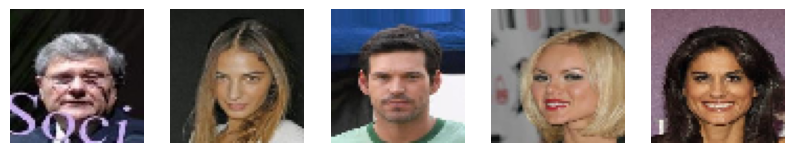

In [15]:
#Display Sample Images
images, _ = next(train_generator)

plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

In [16]:
#Build Convolutional Autoencoder
#Encoder
input_img = Input(shape=(64,64,3))

x = Conv2D(

    32,

    (3,3),

    activation='relu',

    padding='same'

)(input_img)

x = MaxPooling2D(

    (2,2),

    padding='same'

)(x)

x = Conv2D(

    64,

    (3,3),

    activation='relu',

    padding='same'

)(x)

encoded = MaxPooling2D(

    (2,2),

    padding='same'

)(x)

In [17]:
#Decoder
x = Conv2D(

    64,

    (3,3),

    activation='relu',

    padding='same'

)(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(

    32,

    (3,3),

    activation='relu',

    padding='same'

)(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(

    3,

    (3,3),

    activation='sigmoid',

    padding='same'

)(x)

In [18]:
#Create Model
autoencoder = Model(
    input_img,
    decoded
)

In [19]:
#Compile Model
autoencoder.compile(

    optimizer='adam',

    loss='binary_crossentropy'

)

In [20]:
#Model Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Train Model
history = autoencoder.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10

)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 76s 588ms/step - loss: 0.5254 - val_loss: 0.4997
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 75s 600ms/step - loss: 0.4925 - val_loss: 0.4905
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 74s 592ms/step - loss: 0.4890 - val_loss: 0.4874
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 74s 594ms/step - loss: 0.4865 - val_loss: 0.4861
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 84s 610ms/step - loss: 0.4855 - val_loss: 0.4868
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 581ms/step - loss: 0.4850 - val_loss: 0.4849
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 582ms/step - loss: 0.4837 - val_loss: 0.4836
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 74s 591ms/step - loss: 0.4835 - val_loss: 0.4833
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 585ms/step - loss: 0.4830 - val_loss: 0.4831
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 582ms/step - loss: 0.4829 - val_loss: 0.4825


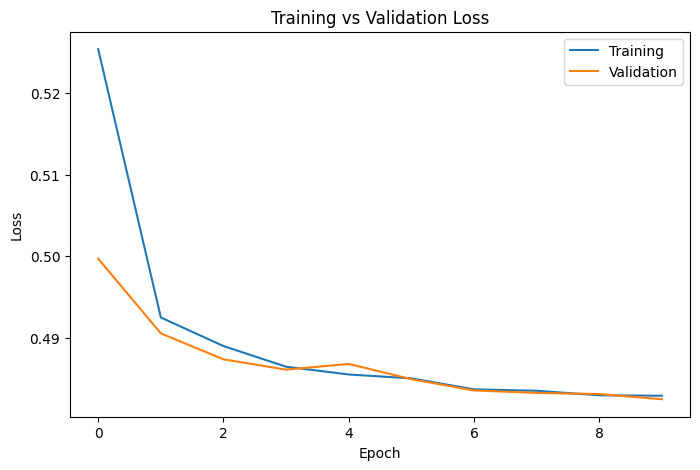

In [22]:
#Plot Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend(["Training","Validation"])

plt.show()

In [23]:
#Evaluate Model
loss = autoencoder.evaluate(validation_generator)

print("Validation Loss :", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.4825
Validation Loss : 0.48247864842414856


In [24]:
#Reconstruct Images
images, _ = next(validation_generator)

reconstructed = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step


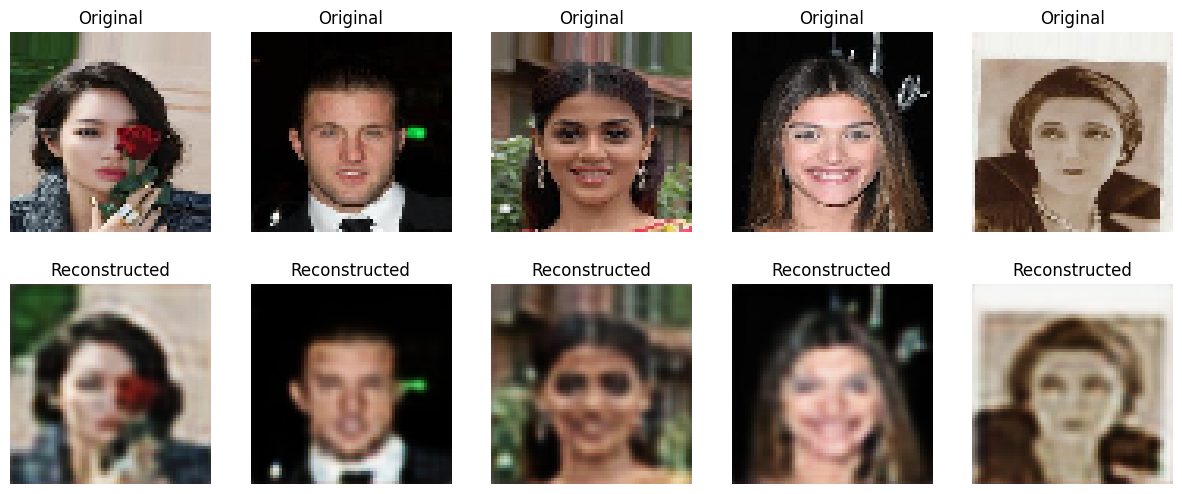

In [25]:
#Display Results
n = 5

plt.figure(figsize=(15,6))

for i in range(n):

    plt.subplot(2,n,i+1)

    plt.imshow(images[i])

    plt.title("Original")

    plt.axis("off")

    plt.subplot(2,n,i+n+1)

    plt.imshow(reconstructed[i])

    plt.title("Reconstructed")

    plt.axis("off")

plt.show()